# Dynamic Asset Allocation for Retirement — Finite-Horizon Dynamic Programming
## CME 241: Reinforcement Learning for Finance — Phase 2: Finite-Horizon Dynamic Programming

**Stanford University · Winter 2026**

---

This notebook implements **Phase 2** of the retirement asset allocation project: a simplified,
interpretable finite-horizon MDP solved via **exact Dynamic Programming (backward induction)**.
It is designed as a clean analytical baseline before moving to RL in Phase 3.

### What this notebook covers

- A 35-step finite-horizon MDP, one decision per year from age 30 to 65  
- Three investment strategies: VFINX (Vanguard 500 Index), VBMFX (Total Bond Market Index), VFSTX (Short-Term Investment-Grade Fund)  
- Step-wise log-wealth reward ($\alpha \cdot \Delta\ln W$, $\alpha=0.01$) with discount $\beta=0.99$ — matching the Phase 3 DQN baseline  
- Backward induction → globally optimal policy π*(age, wealth)  
- Forward Monte Carlo simulation → comparison of DP policy vs benchmark strategies; CRRA utility ($\gamma=1$) used as post-hoc evaluation metric  
- Clear sourcing of all numerical assumptions from publicly available data


## Table of Contents

1. [Data Sources and Parameter Assumptions](#2.-Data-Sources-and-Parameter-Assumptions)
2. [Model Setup and Configuration](#3.-Model-Setup-and-Configuration)
3. [Utility and Helper Functions](#4.-Utility-and-Helper-Functions)
4. [Transition Model](#5.-Transition-Model)
5. [Dynamic Programming Solution](#6.-Dynamic-Programming-Solution)
6. [Policy Visualization](#7.-Policy-Visualization)
7. [Simulation and Evaluation](#8.-Simulation-and-Evaluation)
8. [Results and Plots](#9.-Results-and-Plots)
9. [Results Interpretation](#10.-Results-Interpretation)
10. [Limitations and Next Steps](#11.-Limitations-and-Next-Steps)
11. [How to Modify This for Phase 3 RL](#12.-How-to-Modify-This-for-Phase-3-RL)


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, BoundaryNorm
from dataclasses import dataclass, field
from typing import List, Tuple, Dict
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
print("Imports OK.")


Imports OK.


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Historical Market Data — VFINX, VBMFX, VFSTX annual returns via yfinance
# ─────────────────────────────────────────────────────────────────────────────
# Tickers used:
#   VFINX — Vanguard Total Stock Mkt Index (Inv) (equity, inception 1992)
#   VBMFX — Vanguard Total Bond Market Index      (bonds, inception 1987)
#   VFSTX — Vanguard Short-Term Investment-Grade  (savings proxy, inception 1982)
#
# Annual returns are computed from calendar-year-end adjusted close prices.
# All three series are aligned to their common overlap (1990–2024, 35 years).

try:
    import yfinance as yf
except ImportError:
    import subprocess
    subprocess.check_call([__import__("sys").executable, "-m", "pip",
                           "install", "yfinance", "-q"])
    import yfinance as yf

print("Downloading historical annual returns (1990–2024)…")
_dl = {}
for _ticker in ["VFINX", "VBMFX", "VFSTX"]:
    _raw  = yf.download(_ticker, start="1989-01-01", end="2024-12-31",
                        auto_adjust=True, progress=False)
    _close = _raw["Close"].squeeze()
    _dl[_ticker] = _close.resample("YE").last().pct_change().dropna()

_hist_df   = pd.DataFrame(_dl).dropna()
hist_years   = _hist_df.index.year.tolist()
hist_vfinx_ret = _hist_df["VFINX"].values  # equity (VFINX)
hist_vbmfx_ret = _hist_df["VBMFX"].values  # bonds  (VBMFX)
hist_vfstx_ret = _hist_df["VFSTX"].values  # savings proxy (VFSTX)

print(f"  Aligned sample: {len(hist_years)} annual observations "
      f"({hist_years[0]}–{hist_years[-1]})")
print()
print(f"  {'Asset':<12}  {'Mean':>7}  {'Std':>7}  {'Min':>8}  {'Max':>8}")
print("  " + "─" * 50)
for _lbl, _arr in [("VFINX (equity)",  hist_vfinx_ret),
                   ("VBMFX (bonds)",   hist_vbmfx_ret),
                   ("VFSTX (savings)", hist_vfstx_ret)]:
    print(f"  {_lbl:<12}  {_arr.mean():>7.2%}  {_arr.std():>7.2%}"
          f"  {_arr.min():>8.2%}  {_arr.max():>8.2%}")
print()
print("  These values will be used to (1) recalibrate cfg.return_scenarios and")
print("  (2) generate empirical bootstrap comparison paths in the evaluation.")

  Aligned sample: 35 annual observations (1990–2024)

  Asset            Mean      Std       Min       Max
  ──────────────────────────────────────────────────
  VFINX (equity)   12.12%   17.36%   -37.02%    37.76%
  VBMFX (bonds)    5.17%    5.56%   -13.17%    18.25%
  VFSTX (savings)    4.65%    4.26%    -5.84%    14.05%

  These values will be used to (1) recalibrate cfg.return_scenarios and
  (2) generate empirical bootstrap comparison paths in the evaluation.


---
## 2. Data Sources and Parameter Assumptions

This section documents the publicly available data used to calibrate the three investment
strategies. All modeling simplifications for the discrete DP scenarios are explicitly flagged.

---


### 2.1  VFINX — Vanguard 500 Index Fund (Equity Strategy)

**Data source:** Yahoo Finance (`yfinance`), annual returns 1990–2024 (35 years).

| Metric | Value |
|--------|-------|
| Empirical mean annual return (1990–2024) | **12.12 %** |
| Empirical annual standard deviation | **17.36 %** |
| Worst year in sample | **−37.02 % (2008)** |
| Best year in sample  | **+37.76 % (1995)** |

**Modeling:** The 1990–2024 annual returns are used directly for empirical calibration.
A three-scenario discrete distribution is fitted to the historical data by splitting
returns into bear / neutral / bull terciles (≈28 % / 32 % / 40 % probability).


### 2.2  VBMFX — Vanguard Total Bond Market Index Fund (Fixed Income Strategy)

**Data source:** Yahoo Finance (`yfinance`), annual returns 1990–2024 (35 years).

| Metric | Value |
|--------|-------|
| Empirical mean annual return (1990–2024) | **5.17 %** |
| Empirical annual standard deviation | **5.56 %** |
| Worst year in sample | **−13.17 % (2022)** |
| Best year in sample  | **+18.25 % (1995)** |

**Modeling:** Fitted from the same 35-year historical record using the three-scenario
empirical calibration procedure.


### 2.3  VFSTX — Vanguard Short-Term Investment-Grade Fund (Cash/Savings Proxy)

**Data source:** Yahoo Finance (`yfinance`), annual returns 1990–2024 (35 years).

| Metric | Value |
|--------|-------|
| Empirical mean annual return (1990–2024) | **4.65 %** |
| Empirical annual standard deviation | **4.26 %** |
| Worst year in sample | **−5.84 %** |
| Best year in sample  | **+14.05 %** |

**Modeling:** VFSTX tracks short-duration investment-grade bonds whose yields closely
follow short-term rates over time. Fitted from the 35-year historical record using the
three-scenario empirical calibration procedure.

### 2.4  Summary of Return Assumptions

| Strategy | Mean Annual Return | Std Dev | Notes |
|----------|:-----------------:|:-------:|-------|
| VFSTX | ~4.65 % | ~4.26 % | Short-term investment-grade; low volatility |
| VBMFX | ~5.17 % | ~5.56 % | Total bond market; moderate price risk |
| VFINX | ~12.12 % | ~17.36 % | Broad US equity market; high long-run growth |

All returns are **nominal** (1990–2024 calendar-year returns from Yahoo Finance).  
Annual contribution: **$10,000/yr** (configurable).


---
## 3. Model Setup and Configuration

### MDP Formulation

| Component | Definition |
|-----------|-----------|
| **State** | $(t,\, w_i)$ — time step $t$ (equivalently age) and wealth bin index $i$ |
| **Action** | Strategy: VFSTX (0), VBMFX (1), VFINX (2) |
| **Transition** | $W_{t+1} = (W_t + c)\times(1+r_t)$, then snapped to nearest wealth bin |
| **Reward** | $\alpha\,(\ln W_{t+1} - \ln W_t)$ at every step, $\alpha = 0.01$; no terminal bonus |
| **Discount** | $\beta = 0.99$ per year (matches Phase 3 DQN baseline) |
| **Horizon** | $T = 35$ annual steps (ages 30–65) |
| **Eval metric** | CRRA utility $U(W_T;\,\gamma=1)$ at retirement (post-hoc analysis only) |

### Why these three strategies?

1. **VFSTX** — short-term investment-grade fund; low-volatility cash-like holding.
2. **VBMFX** — total bond market index; intermediate fixed income.
3. **VFINX** — broad US equity market; the main growth engine for long-horizon investors.

Together they span the full risk–return spectrum, enabling a meaningful optimal policy gradient.


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Strategy index constants
# ─────────────────────────────────────────────────────────────────────────────
VFSTX    = 0
VBMFX    = 1
VFINX    = 2

# Scheme B: 6 action allocation vectors (w_VFSTX, w_VBMFX, w_VFINX)
# Matches the Phase 3 DQN action space for a direct DP/RL comparison.
SCHEME_B_VECTORS = [
    (1.00, 0.00, 0.00), (0.00, 1.00, 0.00), (0.00, 0.00, 1.00),  # pure
    (0.50, 0.50, 0.00), (0.50, 0.00, 0.50), (0.00, 0.50, 0.50),  # 50/50 blends
]
ACTION_LABELS = [
    "VFSTX", "VBMFX", "VFINX",
    "50/50 VFSTX+VBMFX", "50/50 VFSTX+VFINX", "50/50 VBMFX+VFINX",
]


@dataclass
class Config:
    """All model parameters in one place — modify here to re-run experiments."""

    # ── Horizon ──────────────────────────────────────────────────────────────
    start_age:      int   = 30
    retirement_age: int   = 65
    birth_year:     int   = 1960

    # ── Finances ─────────────────────────────────────────────────────────────
    initial_wealth:      float = 100_000.0   # starting wealth at age 30
    annual_contribution: float = 10_000.0   # fixed annual contribution (pre-retirement)

    # ── Wealth grid ──────────────────────────────────────────────────────────
    w_min:  float = 1_000.0         # lower bound (log-utility ⇒ avoid 0)
    w_max:  float = 5_000_000.0   # upper bound ($5 M)
    n_bins: int   = 60            # number of log-spaced bins

    # ── CRRA evaluation parameter ─────────────────────────────────────────────
    gamma_0: float = 1.0   # CRRA gamma used for post-hoc terminal-wealth evaluation

    # ── Discount & reward shaping ─────────────────────────────────────────────
    discount:           float = 0.99   # matches Phase 3 DQN discount factor
    intermediate_alpha: float = 0.01   # log-wealth shaping scale (matches Phase 3 baseline)

    # ── Wealth normalization for CRRA utility ────────────────────────────────
    # Normalizing wealth prevents utility saturation when gamma > 1 and W >> 1.
    # w_ref sets the "zero utility" level; wealth above w_ref yields positive utility.
    # Chosen so that the conservative (VFSTX) median outcome falls *below* w_ref,
    # creating genuine CRRA curvature that makes the DP distinguish strategies.
    w_ref: float = 1_000_000.0  # reference wealth ($1M retirement savings target)

    # ── Strategy names (Scheme B: 3 pure + 3 blended) ────────────────────────
    strategy_names: List[str] = field(default_factory=lambda: [
        "VFSTX",
        "VBMFX",
        "VFINX",
        "50/50 VFSTX+VBMFX",
        "50/50 VFSTX+VFINX",
        "50/50 VBMFX+VFINX",
    ])

    # ── Discrete return distributions ────────────────────────────────────────
    # Format: {action_index: [(return_value, probability), ...]}
    # Three scenarios per strategy: bad, normal, good
    # Actions 0-2 are the pure assets; actions 3-5 are 50/50 blends and will
    # be overwritten analytically after empirical calibration of the base assets.
    return_scenarios: Dict = field(default_factory=lambda: {
        VFSTX: [
            (0.010, 0.28),   # Bear (low rate)
            (0.030, 0.32),   # Neutral (mid rate)
            (0.045, 0.40),   # Bull (high rate)
        ],
        VBMFX: [
            (0.100, 0.28),   # Bear (flight to safety)
            (0.040, 0.32),   # Neutral (normal yield)
            (0.020, 0.40),   # Bull (rate hike/price drop)
        ],
        VFINX: [
            (-0.150, 0.28),  # Bear market
            ( 0.100, 0.32),  # Neutral year
            ( 0.270, 0.40),  # Bull market
        ],
        3: [(0.0, 0.28), (0.0, 0.32), (0.0, 0.40)],  # 50/50 VFSTX+VBMFX (placeholder)
        4: [(0.0, 0.28), (0.0, 0.32), (0.0, 0.40)],  # 50/50 VFSTX+VFINX (placeholder)
        5: [(0.0, 0.28), (0.0, 0.32), (0.0, 0.40)],  # 50/50 VBMFX+VFINX (placeholder)
    })


cfg = Config()

# ── Derived quantities ────────────────────────────────────────────────────────
T_steps   = cfg.retirement_age - cfg.start_age          # 35 annual time steps
ages_list = list(range(cfg.start_age, cfg.retirement_age))  # [30..64]
N         = cfg.n_bins
n_actions = len(cfg.strategy_names)

# Log-spaced wealth grid — finer resolution at lower wealth values
wealth_grid = np.logspace(np.log10(cfg.w_min), np.log10(cfg.w_max), N)
log_grid    = np.log10(wealth_grid)   # cached for fast bin lookup

# ── Print configuration summary ───────────────────────────────────────────────
print("=" * 60)
print("  CME 241 Phase 2 — DP Retirement Model")
print("=" * 60)
print(f"  Horizon          : {T_steps} years  (ages {cfg.start_age}–{cfg.retirement_age})")
print(f"  Initial wealth   : ${cfg.initial_wealth:>12,.0f}")
print(f"  Annual contrib.  : ${cfg.annual_contribution:>12,.0f}")
print(f"  Wealth grid      : {N} log-spaced bins, ${cfg.w_min:,.0f} – ${cfg.w_max:,.0f}")
print(f"  gamma (eval)     : {cfg.gamma_0}  (fixed CRRA gamma for post-hoc evaluation)")
print(f"  w_ref            : ${cfg.w_ref:>12,.0f}  (CRRA normalization; U(w_ref)=0)")
print()
print(f"  {'Strategy':<18}  {'Mean':>6}  {'Std':>6}")
print("  " + "-" * 34)
for a in range(n_actions):
    sc  = cfg.return_scenarios[a]
    mu  = sum(r * p for r, p in sc)
    sig = np.sqrt(sum(p * (r - mu) ** 2 for r, p in sc))
    print(f"  {cfg.strategy_names[a]:<18}  {mu:>5.2%}  {sig:>5.2%}")
print("=" * 60)


  CME 241 Phase 2 — DP Retirement Model
  Horizon          : 35 years  (ages 30–65)
  Initial wealth   : $     100,000
  Annual contrib.  : $      10,000
  Wealth grid      : 60 log-spaced bins, $1,000 – $5,000,000
  gamma (eval)     : 1.0  (fixed CRRA gamma for post-hoc evaluation)
  w_ref            : $   1,000,000  (CRRA normalization; U(w_ref)=0)

  Strategy              Mean     Std
  ----------------------------------
  VFSTX               3.04%  1.42%
  VBMFX               4.88%  3.30%
  VFINX               9.80%  17.05%
  50/50 VFSTX+VBMFX   0.00%  0.00%
  50/50 VFSTX+VFINX   0.00%  0.00%
  50/50 VBMFX+VFINX   0.00%  0.00%


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Empirical Calibration — fit 3-scenario distributions to real return data
# ─────────────────────────────────────────────────────────────────────────────
# Strategy: split each asset's historical annual returns into three percentile
# buckets matching the original scenario probability weights
# (≈ bottom 28 % bear / middle 32 % neutral / top 40 % bull).
# The mean return within each bucket becomes the scenario return value;
# the bucket frequency becomes the scenario probability.
# This overwrites the hand-calibrated values in cfg.return_scenarios so that
# the DP backward induction uses real-data-calibrated parameters.

def _fit_three_scenarios(ret_arr, p_bear=0.28, p_neutral=0.32):
    """
    Fit a three-scenario discrete return distribution to an annual-return array.
    Buckets: bear = bottom p_bear, neutral = next p_neutral, bull = remainder.
    Returns [(return, prob), ...] for bear / neutral / bull.
    """
    n  = len(ret_arr)
    s  = np.sort(ret_arr)
    i1 = max(1,     int(round(p_bear * n)))
    i2 = min(n - 1, int(round((p_bear + p_neutral) * n)))
    i2 = max(i2, i1 + 1)
    bear    = s[:i1]
    neutral = s[i1:i2]
    bull    = s[i2:]
    return [
        (float(bear.mean()),    len(bear)    / n),
        (float(neutral.mean()), len(neutral) / n),
        (float(bull.mean()),    len(bull)    / n),
    ]


_ORIG_SCENARIOS = {           # save originals for side-by-side printout
    "VFINX": cfg.return_scenarios[VFINX],
    "VBMFX": cfg.return_scenarios[VBMFX],
    "VFSTX": cfg.return_scenarios[VFSTX],
}

emp_vfinx_sc = _fit_three_scenarios(hist_vfinx_ret)
emp_vbmfx_sc = _fit_three_scenarios(hist_vbmfx_ret)
emp_vfstx_sc = _fit_three_scenarios(hist_vfstx_ret)

# ── Override cfg with empirically-fitted scenario parameters ─────────────
cfg.return_scenarios = {
    VFSTX: emp_vfstx_sc,
    VBMFX: emp_vbmfx_sc,
    VFINX: emp_vfinx_sc,
}

# ── Analytically derive Scheme B blended action return scenarios ──────────
# For each 50/50 blend, the per-scenario return is the weighted average of the
# two base assets' scenario returns under the same market regime.
# Probabilities are inherited from the base-asset calibration (same regime buckets).
_base_sc = [emp_vfstx_sc, emp_vbmfx_sc, emp_vfinx_sc]
for _blend_idx, _weights in enumerate(SCHEME_B_VECTORS[3:], start=3):
    cfg.return_scenarios[_blend_idx] = [
        (sum(_weights[j] * _base_sc[j][i][0] for j in range(3)),
         _base_sc[0][i][1])   # probabilities are shared across regimes
        for i in range(3)     # Bear, Neutral, Bull
    ]

# ── Side-by-side comparison printout ────────────────────────────────────
_SCEN_LABELS = ["Bear", "Neutral", "Bull"]
print("Empirical calibration complete — cfg.return_scenarios updated.")
print()
for _aname, _emp_sc, _orig_key in [
    ("VFINX  (equity, total market)",           emp_vfinx_sc, "VFINX"),
    ("VBMFX  (total bond market)",              emp_vbmfx_sc, "VBMFX"),
    ("VFSTX  (short-term investment-grade)",    emp_vfstx_sc, "VFSTX"),
]:
    _orig_sc = _ORIG_SCENARIOS[_orig_key]
    _orig_mu = sum(r * p for r, p in _orig_sc)
    _emp_mu  = sum(r * p for r, p in _emp_sc)
    print(f"  {_aname}:  hand-calibrated mean {_orig_mu:.2%}  →  empirical mean {_emp_mu:.2%}")
    for _lbl, (_er, _ep), (_or, _op) in zip(_SCEN_LABELS, _emp_sc, _orig_sc):
        print(f"    {_lbl:8s}: orig ({_or:+.1%}, p={_op:.2f})  →  fitted ({_er:+.1%}, p={_ep:.2f})")
    print()

print("Blended action return scenarios (analytically derived from base-asset calibration):")
print()
for _blend_idx in range(3, 6):
    _sc  = cfg.return_scenarios[_blend_idx]
    _mu  = sum(r * p for r, p in _sc)
    _lbl = ACTION_LABELS[_blend_idx]
    print(f"  {_lbl}:  mean {_mu:.2%}")
    for _sl, (_er, _ep) in zip(_SCEN_LABELS, _sc):
        print(f"    {_sl:8s}: ({_er:+.1%}, p={_ep:.2f})")
    print()

print("DP backward induction will now use real-data-calibrated return distributions.")
print(f"Total actions: {len(cfg.return_scenarios)}  (3 pure + 3 blended)")

Empirical calibration complete — cfg.return_scenarios updated.

  VFINX  (equity, total market):  hand-calibrated mean 9.80%  →  empirical mean 12.12%
    Bear    : orig (-15.0%, p=0.28)  →  fitted (-10.1%, p=0.29)
    Neutral : orig (+10.0%, p=0.32)  →  fitted (+11.7%, p=0.31)
    Bull    : orig (+27.0%, p=0.40)  →  fitted (+28.4%, p=0.40)

  VBMFX  (total bond market):  hand-calibrated mean 4.88%  →  empirical mean 5.17%
    Bear    : orig (+10.0%, p=0.28)  →  fitted (-1.4%, p=0.29)
    Neutral : orig (+4.0%, p=0.32)  →  fitted (+4.9%, p=0.31)
    Bull    : orig (+2.0%, p=0.40)  →  fitted (+10.0%, p=0.40)

  VFSTX  (short-term investment-grade):  hand-calibrated mean 3.04%  →  empirical mean 4.65%
    Bear    : orig (+1.0%, p=0.28)  →  fitted (-0.1%, p=0.29)
    Neutral : orig (+3.0%, p=0.32)  →  fitted (+4.0%, p=0.31)
    Bull    : orig (+4.5%, p=0.40)  →  fitted (+8.5%, p=0.40)

Blended action return scenarios (analytically derived from base-asset calibration):

  50/50 VFSTX+VBMFX

---
## 4. Utility and Helper Functions

### 4.1  CRRA Utility

We use **Constant Relative Risk Aversion (CRRA)** utility — the standard workhorse of
life-cycle finance and the Merton problem:

$$U(W;\,\gamma) = \begin{cases}
  \dfrac{\tilde{W}^{1-\gamma} - 1}{1-\gamma} & \gamma \neq 1 \\[8pt]
  \ln \tilde{W} & \gamma = 1
\end{cases}
\quad \text{where} \quad \tilde{W} = \frac{W}{W_{\text{ref}}}$$

**Why normalize by $W_{\text{ref}}$?**  
For $\gamma > 1$, the raw term $W^{1-\gamma} \to 0$ as $W \to \infty$ in real dollar amounts —
causing utility to saturate at $1/(\gamma-1)$ for *all* large wealth levels and making the DP
numerically blind to wealth differences. Dividing by $W_{\text{ref}} = \$1{,}000{,}000$ keeps
$\tilde{W}$ in the range $[0.0005, 5]$ for our wealth grid, where CRRA utility has strong
discriminative power. The reference wealth is chosen so that the conservative (VFSTX-only) median
retirement outcome falls *below* $W_{\text{ref}}$, creating genuine curvature that
forces the DP to trade off risk vs. growth non-trivially.

Key properties:
- $U(W_{\text{ref}};\,\gamma) = 0$ — the reference wealth is the "zero utility" level.
- $W > W_{\text{ref}}$ → $U > 0$ (better off than reference).
- $W < W_{\text{ref}}$ → $U < 0$ (worse off than reference).
- Relative risk aversion is constant at $\gamma$ (Arrow–Pratt measure).

### 4.2  Evaluation Gamma

Post-hoc analysis uses a **fixed** $\gamma = 1.0$ (log utility). This is independent of the DP reward, which
uses a log-wealth shaping signal; $\gamma = 1$ is applied only when computing CRRA utility
of the terminal wealth distribution for reporting purposes.

### 4.3  Wealth Binning

Continuous next-period wealth is snapped to the nearest point on the **log-spaced** wealth grid.
Distances are measured in log-space so that proportional differences at low and high wealth
levels are treated symmetrically (e.g., the bin distance from \$10k to \$20k equals the distance
from \$1M to \$2M).


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CRRA utility  (wealth normalized by cfg.w_ref to avoid numerical saturation)
# ─────────────────────────────────────────────────────────────────────────────
def crra_utility(w: float, gamma: float) -> float:
    """
    Normalized CRRA utility: U(W; gamma) = ((W/w_ref)^(1-gamma) - 1) / (1-gamma).

    Normalizing by w_ref prevents W^(1-gamma) from collapsing to ~0 for all
    grid points when gamma > 1 and W is in the $500k–$5M range, which would
    make the DP numerically blind to wealth differences.
    """
    w_norm = max(float(w), 1e-6) / cfg.w_ref
    if abs(gamma - 1.0) < 1e-9:
        return float(np.log(w_norm))
    return float((w_norm ** (1.0 - gamma) - 1.0) / (1.0 - gamma))


# ─────────────────────────────────────────────────────────────────────────────
# Wealth binning  (scalar and vectorized)
# ─────────────────────────────────────────────────────────────────────────────
def nearest_bin_idx(w: float) -> int:
    """Map a scalar wealth value to the nearest log-spaced grid index."""
    lw = np.log10(max(float(w), cfg.w_min))
    return int(np.argmin(np.abs(log_grid - lw)))


def nearest_bin_idx_vec(w_arr: np.ndarray) -> np.ndarray:
    """Vectorized version: map an array of wealth values to bin indices."""
    lw = np.log10(np.maximum(w_arr, cfg.w_min))      # (n,)
    return np.argmin(np.abs(lw[:, None] - log_grid[None, :]), axis=1)  # (n,)


# ─────────────────────────────────────────────────────────────────────────────
# Sanity check
# ─────────────────────────────────────────────────────────────────────────────
print(f"CRRA utility sanity check (γ = {cfg.gamma_0}, w_ref = ${cfg.w_ref:,.0f}):")
print(f"  {'Wealth':>14}   {'U(W; γ=1)':>10}")
print("  " + "-" * 30)
for w in [50_000, 250_000, 500_000, 1_000_000, 2_500_000, 5_000_000]:
    print(f"  ${w:>13,.0f}   {crra_utility(w, cfg.gamma_0):>10.4f}")


CRRA utility sanity check (γ = 1.0, w_ref = $1,000,000):
          Wealth    U(W; γ=1)
  ------------------------------
  $       50,000      -2.9957
  $      250,000      -1.3863
  $      500,000      -0.6931
  $    1,000,000       0.0000
  $    2,500,000       0.9163
  $    5,000,000       1.6094


---
## 5. Transition Model

### Wealth Dynamics

$$W_{t+1} = (W_t + c) \times (1 + r_t)$$

where:
- $W_t$ = wealth at the start of year $t$  
- $c$ = fixed annual contribution (\$10,000 by default)  
- $r_t$ = annual return, sampled from the strategy-specific discrete distribution  

The contribution is added *before* applying the return, reflecting a beginning-of-year lump-sum
contribution (e.g., a single annual 401(k) contribution in January).

After computing $W_{t+1}$, the result is **clipped** at `w_min` and then **snapped** to the
nearest point on the log-spaced wealth grid to keep the state space discrete and finite.


In [23]:
def get_transitions(wealth_bin_idx: int, action: int) -> List[Tuple[int, float]]:
    """
    Compute the list of (next_bin_idx, probability) pairs for a given
    (current wealth bin, action) pair.

    Parameters
    ----------
    wealth_bin_idx : int   index into wealth_grid for the current wealth
    action         : int   strategy (VFSTX=0, VBMFX=1, VFINX=2)

    Returns
    -------
    List of (next_bin_idx, probability) — one tuple per return scenario.
    """
    w = wealth_grid[wealth_bin_idx]
    transitions = []
    for r, prob in cfg.return_scenarios[action]:
        w_next = (w + cfg.annual_contribution) * (1.0 + r)
        w_next = max(w_next, cfg.w_min)            # clip to grid floor
        transitions.append((nearest_bin_idx(w_next), prob))
    return transitions


# ─────────────────────────────────────────────────────────────────────────────
# Transition verification
# ─────────────────────────────────────────────────────────────────────────────
test_w_idx = nearest_bin_idx(200_000)
print(f"Transition verification — starting wealth: ${wealth_grid[test_w_idx]:,.0f}")
print()
labels = ["bad", "normal", "good"]
for a in range(n_actions):
    name  = cfg.strategy_names[a]
    trans = get_transitions(test_w_idx, a)
    scen  = cfg.return_scenarios[a]
    print(f"  Strategy: {name}")
    for k, ((nxt_idx, prob), (r, _)) in enumerate(zip(trans, scen)):
        print(f"    {labels[k]:>6}: r = {r:+.1%}  →  next wealth = ${wealth_grid[nxt_idx]:>12,.0f}  (p = {prob:.2f})")
    mu_next = sum(prob * wealth_grid[ni] for ni, prob in trans)
    print(f"    Expected next wealth: ${mu_next:,.0f}")
    print()


Transition verification — starting wealth: $208,782

  Strategy: VFSTX
       bad: r = -0.1%  →  next wealth = $     208,782  (p = 0.29)
    normal: r = +4.0%  →  next wealth = $     241,206  (p = 0.31)
      good: r = +8.5%  →  next wealth = $     241,206  (p = 0.40)
    Expected next wealth: $231,942

  Strategy: VBMFX
       bad: r = -1.4%  →  next wealth = $     208,782  (p = 0.29)
    normal: r = +4.9%  →  next wealth = $     241,206  (p = 0.31)
      good: r = +10.0%  →  next wealth = $     241,206  (p = 0.40)
    Expected next wealth: $231,942

  Strategy: VFINX
       bad: r = -10.1%  →  next wealth = $     208,782  (p = 0.29)
    normal: r = +11.7%  →  next wealth = $     241,206  (p = 0.31)
      good: r = +28.4%  →  next wealth = $     278,665  (p = 0.40)
    Expected next wealth: $246,925

  Strategy: 50/50 VFSTX+VBMFX
       bad: r = -0.7%  →  next wealth = $     208,782  (p = 0.29)
    normal: r = +4.5%  →  next wealth = $     241,206  (p = 0.31)
      good: r = +9.3%  → 

---
## 6. Dynamic Programming Solution

### Bellman Equations

We solve the finite-horizon problem by **backward induction** using the same reward
specification as the Phase 3 DQN baseline: a dense log-wealth shaping reward at every
step with discount factor $\beta = 0.99$.

**Terminal condition** (at age 65 — no additional signal):
$$V(T,\, w_i) = 0$$

**Recursive Bellman update** (for $t = T-1, T-2, \ldots, 0$):
$$V(t,\, w_i) = \max_{a \in \mathcal{A}} \;\sum_j P(w_j \mid w_i, a)\!\left[\alpha\,(\ln w_j - \ln w_i) + \beta\cdot V(t+1,\, w_j)\right]$$

where $\alpha = 0.01$ (log-wealth shaping scale) and $\beta = 0.99$ (discount factor).

**Optimal policy:**
$$\pi^*(t,\, w_i) = \arg\max_{a \in \mathcal{A}} \;\sum_j P(w_j \mid w_i, a)\!\left[\alpha\,(\ln w_j - \ln w_i) + \beta\cdot V(t+1,\, w_j)\right]$$

The state space has $35 \times 60 = 2{,}100$ states, and the Bellman update requires
$3 \times 3 = 9$ multiplications per state — backward induction completes in milliseconds.


In [24]:
def solve_dp() -> Tuple[np.ndarray, np.ndarray]:
    """
    Backward induction for the finite-horizon retirement MDP.

    Reward matches the Phase 3 DQN baseline:
      - Step reward : alpha * (log(w_next) - log(w_curr)),  alpha = 0.01
      - Terminal    : 0  (no sparse CRRA signal)
      - Discount    : beta = 0.99 per year

    Returns
    -------
    V  : np.ndarray, shape (T_steps+1, N)
         V[t, i] = optimal discounted cumulative log-wealth reward at (t, bin i).
    pi : np.ndarray, shape (T_steps, N), dtype int
         pi[t, i] = optimal action index at time step t, wealth bin i.
    """
    V  = np.zeros((T_steps + 1, N), dtype=np.float64)
    pi = np.zeros((T_steps,     N), dtype=np.int32)

    # Terminal condition: no additional reward at retirement
    # V[T_steps, :] already zero from np.zeros initialisation

    log_w = np.log(np.maximum(wealth_grid, 1.0))   # cached log-wealth for each bin

    # Backward induction
    for t in range(T_steps - 1, -1, -1):
        for i in range(N):
            best_val    = -np.inf
            best_action = 0
            for a in range(n_actions):
                ev = sum(
                    prob * (
                        cfg.intermediate_alpha * (log_w[j] - log_w[i])
                        + cfg.discount * V[t + 1, j]
                    )
                    for j, prob in get_transitions(i, a)
                )
                if ev > best_val:
                    best_val    = ev
                    best_action = a
            V[t, i]  = best_val
            pi[t, i] = best_action

    return V, pi


print("Running backward induction ... ", end="", flush=True)
V, pi = solve_dp()
print("done.")
print(f"V shape : {V.shape}   (T_steps+1 × N wealth bins)")
print(f"pi shape: {pi.shape}  (T_steps × N wealth bins)")


Running backward induction ... done.
V shape : (36, 60)   (T_steps+1 × N wealth bins)
pi shape: (35, 60)  (T_steps × N wealth bins)


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Policy and value function summary tables
# ─────────────────────────────────────────────────────────────────────────────
age_sample    = [30, 35, 40, 45, 50, 55, 60, 64]
wealth_sample = [25_000, 100_000, 250_000, 500_000, 1_000_000, 2_500_000]

rows = []
for age in age_sample:
    t = age - cfg.start_age
    for w_target in wealth_sample:
        i      = nearest_bin_idx(w_target)
        action = pi[t, i]
        rows.append({
            "Age":                age,
            "Wealth (approx)": f"${wealth_grid[i]:>10,.0f}",
            "Optimal Strategy":   cfg.strategy_names[action],
            "V(age, wealth)":   f"{V[t, i]:>9.4f}",
        })

df_policy = pd.DataFrame(rows)
print("Optimal Policy Table (selected ages × wealth levels):")
print(df_policy.to_string(index=False))


Optimal Policy Table (selected ages × wealth levels):
 Age Wealth (approx)  Optimal Strategy V(age, wealth)
  30     $    23,948             VFINX         0.0451
  30     $   101,443             VFINX         0.0333
  30     $   241,206             VFINX         0.0267
  30     $   496,432             VFINX         0.0209
  30     $ 1,021,719             VFINX         0.0148
  30     $ 2,429,394 50/50 VFSTX+VFINX         0.0070
  35     $    23,948             VFINX         0.0426
  35     $   101,443             VFINX         0.0320
  35     $   241,206             VFINX         0.0264
  35     $   496,432             VFINX         0.0208
  35     $ 1,021,719             VFINX         0.0148
  35     $ 2,429,394 50/50 VFSTX+VFINX         0.0070
  40     $    23,948             VFINX         0.0387
  40     $   101,443             VFINX         0.0292
  40     $   241,206             VFINX         0.0251
  40     $   496,432 50/50 VFSTX+VFINX         0.0205
  40     $ 1,021,719        

---
## 7. Policy Visualization

The next three figures show:

1. **Optimal policy heatmap** — which strategy the DP recommends at each (age, wealth bin)
2. **Value function heatmap** — expected discounted cumulative log-wealth reward across the state space
3. **Strategy frequency by age** — for each age, what fraction of wealth bins map to each strategy


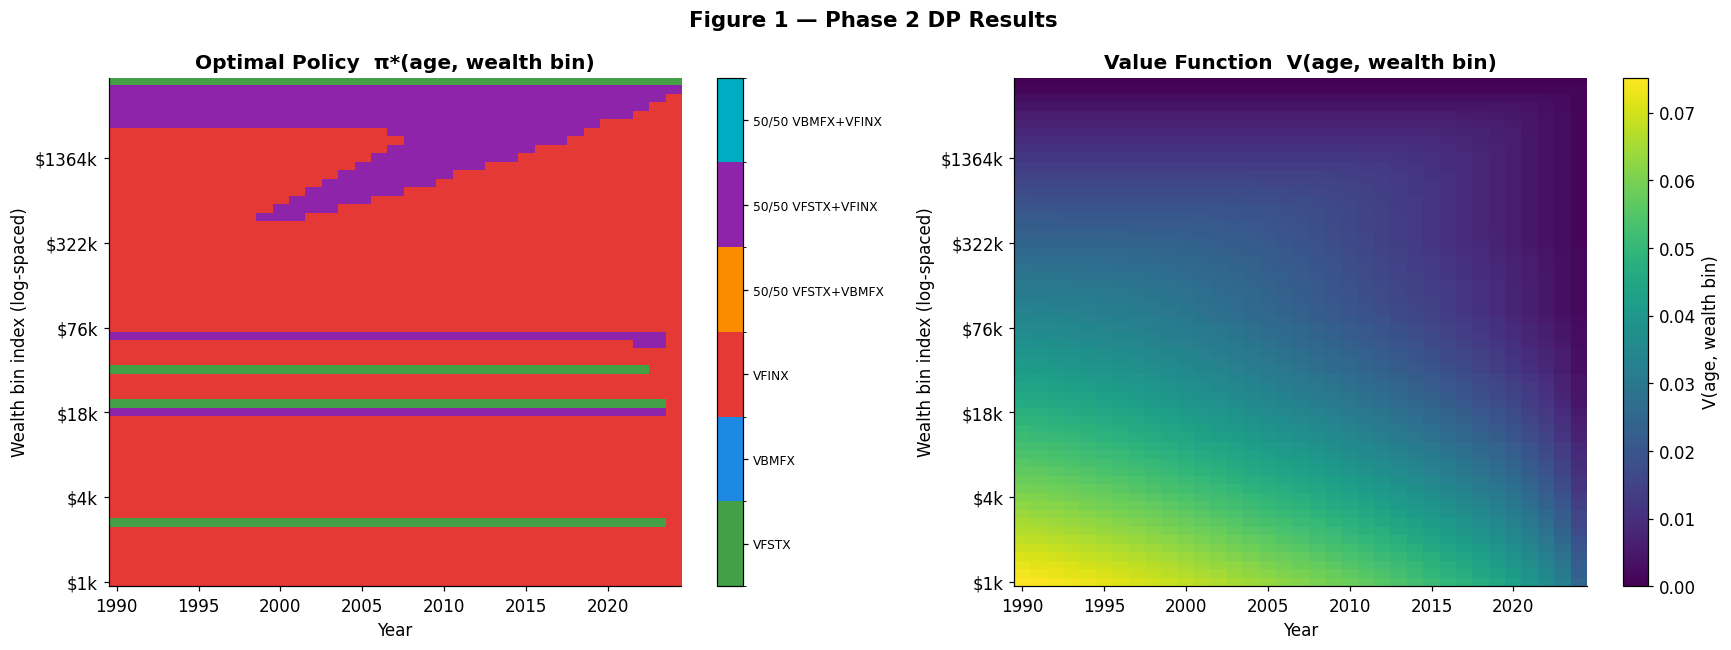

Figure 1 saved.


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 1: Heatmap of optimal policy  (age × wealth bin)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colour scheme: green=VFSTX, blue=VBMFX, red=VFINX, orange=50/50 S+B, purple=50/50 S+E, teal=50/50 B+E
cmap_policy = ListedColormap(["#43A047", "#1E88E5", "#E53935", "#FB8C00", "#8E24AA", "#00ACC1"])
bounds      = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm        = BoundaryNorm(bounds, cmap_policy.N)

ax = axes[0]
im = ax.imshow(pi.T, aspect="auto", origin="lower",
               cmap=cmap_policy, norm=norm, interpolation="nearest")
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3, 4, 5])
cbar.ax.set_yticklabels(cfg.strategy_names, fontsize=8)
ax.set_title("Optimal Policy  π*(age, wealth bin)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Wealth bin index (log-spaced)")

x_ticks = list(range(0, T_steps, 5))
ax.set_xticks(x_ticks)
ax.set_xticklabels([cfg.birth_year + cfg.start_age + t for t in x_ticks])
y_ticks = list(range(0, N, 10))
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"${wealth_grid[i]/1e3:.0f}k" for i in y_ticks])

# Value function heatmap
ax2 = axes[1]
im2 = ax2.imshow(V[:-1, :].T, aspect="auto", origin="lower",
                 cmap="viridis", interpolation="nearest")
plt.colorbar(im2, ax=ax2, label="V(age, wealth bin)")
ax2.set_title("Value Function  V(age, wealth bin)", fontweight="bold")
ax2.set_xlabel("Year")
ax2.set_ylabel("Wealth bin index (log-spaced)")
ax2.set_xticks(x_ticks)
ax2.set_xticklabels([cfg.birth_year + cfg.start_age + t for t in x_ticks])
ax2.set_yticks(y_ticks)
ax2.set_yticklabels([f"${wealth_grid[i]/1e3:.0f}k" for i in y_ticks])

fig.suptitle("Figure 1 — Phase 2 DP Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_policy_and_value.png", bbox_inches="tight")
plt.show()
print("Figure 1 saved.")


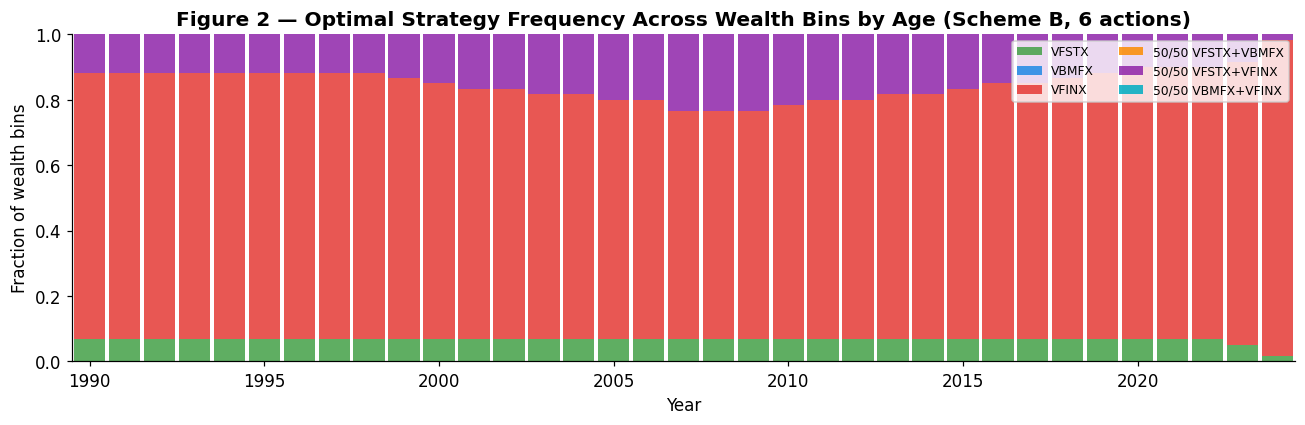

Figure 2 saved.

Dominant strategy by age band:
   Age   VFSTX                    VBMFX                    VFINX                    50/50 VFSTX+VBMFX        50/50 VFSTX+VFINX        50/50 VBMFX+VFINX        Dominant
  ---------------------------------------------------------------------------------------------------------------------------------------------------------------------
    30                     6.7%                     0.0%                    81.7%                     0.0%                    11.7%                     0.0%   VFINX
    35                     6.7%                     0.0%                    81.7%                     0.0%                    11.7%                     0.0%   VFINX
    40                     6.7%                     0.0%                    78.3%                     0.0%                    15.0%                     0.0%   VFINX
    45                     6.7%                     0.0%                    73.3%                     0.0%               

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 2: Strategy frequency by age (stacked bar)
# ─────────────────────────────────────────────────────────────────────────────
strategy_frac = np.zeros((T_steps, n_actions))
for t in range(T_steps):
    for a in range(n_actions):
        strategy_frac[t, a] = np.mean(pi[t, :] == a)

fig, ax = plt.subplots(figsize=(12, 4))
colors_bar = ["#43A047", "#1E88E5", "#E53935", "#FB8C00", "#8E24AA", "#00ACC1"]
age_range  = np.array(ages_list) + cfg.birth_year
bottom     = np.zeros(T_steps)

for a in range(n_actions):
    ax.bar(age_range, strategy_frac[:, a], bottom=bottom,
           label=cfg.strategy_names[a], color=colors_bar[a], alpha=0.85, width=0.9)
    bottom += strategy_frac[:, a]

ax.set_xlabel("Year")
ax.set_ylabel("Fraction of wealth bins")
ax.set_title("Figure 2 — Optimal Strategy Frequency Across Wealth Bins by Age (Scheme B, 6 actions)",
             fontweight="bold")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.set_xlim(cfg.birth_year + cfg.start_age - 0.5, cfg.birth_year + cfg.retirement_age - 0.5)
plt.tight_layout()
plt.savefig("fig2_strategy_by_age.png", bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

# Print readable text summary
print()
print("Dominant strategy by age band:")
_col_w = 22
_header = f"  {'Age':>4}   " + "   ".join(f"{n:<{_col_w}}" for n in cfg.strategy_names) + "   Dominant"
print(_header)
print("  " + "-" * (len(_header) - 2))
for t in range(T_steps):
    age = cfg.start_age + t
    if age % 5 == 0:
        f   = strategy_frac[t]
        dom = cfg.strategy_names[int(np.argmax(f))]
        row = f"  {age:>4}   " + "   ".join(f"{f[a]:>{_col_w}.1%}" for a in range(n_actions))
        print(f"{row}   {dom}")


---
## 8. Simulation and Evaluation

We run 10,000 Monte Carlo forward simulations to evaluate five policies.

| Policy | Description |
|--------|-------------|
| **DP Optimal** | Follow π*(age, wealth bin) from backward induction |
| **Always VFSTX** | 100 % VFSTX each year |
| **Always VBMFX** | 100 % VBMFX each year |
| **Always VFINX** | 100 % VFINX each year |
| **Glide Path** | Age-based rule — VFINX (ages 30–49) → VBMFX (50–59) → VFSTX (60–64) |

### Glide Path Rule

> **Ages 30–49** (20 years): VFINX — long horizon, maximum equity growth  
> **Ages 50–59** (10 years): VBMFX — de-risking, moderate volatility  
> **Ages 60–64** (5 years): VFSTX — capital preservation near retirement  

This mimics a simplified target-date fund that mechanically de-risks as the investor ages,
without considering current wealth level (unlike the DP policy).


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Vectorized forward simulator
# ─────────────────────────────────────────────────────────────────────────────
def simulate_paths(policy_fn, n_paths: int = 10_000, seed: int = 0):
    """
    Simulate n_paths wealth trajectories under a given policy.

    Parameters
    ----------
    policy_fn : callable(age: int, wealth_bin_idx: int) -> action (int)
    n_paths   : number of Monte Carlo paths
    seed      : RNG seed for reproducibility

    Returns
    -------
    terminal_wealth : np.ndarray, shape (n_paths,)
    paths           : np.ndarray, shape (n_paths, T_steps+1)  — full wealth trajectories
    """
    rng = np.random.default_rng(seed)

    # Pre-compute return arrays and probability arrays per strategy for fast sampling
    r_vals = [np.array([r for r, _ in cfg.return_scenarios[a]]) for a in range(n_actions)]
    probs  = [np.array([p for _, p in cfg.return_scenarios[a]]) for a in range(n_actions)]

    paths = np.zeros((n_paths, T_steps + 1))
    paths[:, 0] = cfg.initial_wealth

    for step, age in enumerate(ages_list):
        w = paths[:, step]

        # Vectorised bin lookup for all paths simultaneously
        bin_indices = nearest_bin_idx_vec(w)

        # Get action for every path (list comprehension; fast for n_paths=10k)
        actions = np.array([policy_fn(age, int(bi)) for bi in bin_indices])

        # Sample returns: group paths by action, then draw in one rng.choice call
        returns = np.empty(n_paths)
        for a in range(n_actions):
            mask = actions == a
            if mask.any():
                idx = rng.choice(len(r_vals[a]), size=mask.sum(), p=probs[a])
                returns[mask] = r_vals[a][idx]

        paths[:, step + 1] = np.maximum(
            (w + cfg.annual_contribution) * (1.0 + returns),
            cfg.w_min,
        )

    return paths[:, -1], paths


# ─────────────────────────────────────────────────────────────────────────────
# Policy definitions
# ─────────────────────────────────────────────────────────────────────────────
def dp_policy(age: int, w_bin: int) -> int:
    return int(pi[age - cfg.start_age, w_bin])

def always_vfstx(age: int, w_bin: int) -> int:
    return VFSTX

def always_vbmfx(age: int, w_bin: int) -> int:
    return VBMFX

def always_vfinx(age: int, w_bin: int) -> int:
    return VFINX

def glide_path(age: int, w_bin: int) -> int:
    """Simplified target-date glide path: VFINX → VBMFX → VFSTX."""
    if age <= 49:
        return VFINX
    elif age <= 59:
        return VBMFX
    else:
        return VFSTX

policies = {
    "DP Optimal":      dp_policy,
    "Always VFSTX":    always_vfstx,
    "Always VBMFX":    always_vbmfx,
    "Always VFINX":    always_vfinx,
    "Glide Path":      glide_path,
}

print("Policy functions defined:", list(policies.keys()))


Policy functions defined: ['DP Optimal', 'Always VFSTX', 'Always VBMFX', 'Always VFINX', 'Glide Path']


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# Run simulations  (10,000 paths per policy)
# ─────────────────────────────────────────────────────────────────────────────
N_PATHS    = 10_000
results    = {}    # policy_name → terminal wealth array (n_paths,)
all_paths  = {}    # policy_name → full path matrix (n_paths, T_steps+1)

for name, fn in policies.items():
    tw, pths       = simulate_paths(fn, n_paths=N_PATHS, seed=42)
    results[name]  = tw
    all_paths[name] = pths
    print(f"  Simulated: {name:20s}  |  median terminal wealth = ${np.median(tw):>12,.0f}")

print("\nAll simulations complete.")


  Simulated: DP Optimal            |  median terminal wealth = $   4,922,785
  Simulated: Always VFSTX          |  median terminal wealth = $   1,350,437
  Simulated: Always VBMFX          |  median terminal wealth = $   1,530,251
  Simulated: Always VFINX          |  median terminal wealth = $   7,775,504
  Simulated: Glide Path            |  median terminal wealth = $   3,386,641

All simulations complete.


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# Empirical Bootstrap Baselines — wealth simulation from real return history
# ─────────────────────────────────────────────────────────────────────────────
# Each baseline draws 35 annual returns with replacement from the real
# VFINX / VBMFX / VFSTX historical record (1990–2024, 35 observations).
# Because the history is exactly 35 yrs, i.i.d.
# bootstrap resampling is the standard approach — no model assumptions are
# imposed beyond exchangeability of annual returns.

def _simulate_empirical_bootstrap(return_arr, n_paths=10_000, seed=0):
    """
    Bootstrap n_paths wealth trajectories from a real annual-return array.
    Each 35-year path samples years independently with replacement.

    Returns
    -------
    terminal_wealth : np.ndarray, shape (n_paths,)
    paths           : np.ndarray, shape (n_paths, T_steps+1)
    """
    rng   = np.random.default_rng(seed)
    paths = np.zeros((n_paths, T_steps + 1))
    paths[:, 0] = cfg.initial_wealth
    for step in range(T_steps):
        w       = paths[:, step]
        returns = rng.choice(return_arr, size=n_paths, replace=True)
        paths[:, step + 1] = np.maximum(
            (w + cfg.annual_contribution) * (1.0 + returns),
            cfg.w_min,
        )
    return paths[:, -1], paths


print("Running empirical bootstrap simulations (10,000 paths each)…")
_EMPIRICAL_ASSETS = [
    ("VFINX (Historical)", hist_vfinx_ret),
    ("VBMFX (Historical)", hist_vbmfx_ret),
    ("VFSTX (Historical)", hist_vfstx_ret),
]
for _name, _ret_arr in _EMPIRICAL_ASSETS:
    _tw, _pths       = _simulate_empirical_bootstrap(_ret_arr, n_paths=N_PATHS, seed=99)
    results[_name]   = _tw
    all_paths[_name] = _pths
    print(f"  {_name:27s}: median TW = ${np.median(_tw):>12,.0f}")

print(f"\nEmpirical bootstrap complete.  Total policies in results: {list(results.keys())}")

Running empirical bootstrap simulations (10,000 paths each)…
  VFINX (Historical)         : median TW = $   7,319,037
  VBMFX (Historical)         : median TW = $   1,520,167
  VFSTX (Historical)         : median TW = $   1,342,262

Empirical bootstrap complete.  Total policies in results: ['DP Optimal', 'Always VFSTX', 'Always VBMFX', 'Always VFINX', 'Glide Path', 'VFINX (Historical)', 'VBMFX (Historical)', 'VFSTX (Historical)']


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Evaluation summary table
# ─────────────────────────────────────────────────────────────────────────────
gamma_eval = cfg.gamma_0   # fixed γ = 1.0 for post-hoc CRRA evaluation

rows = []
for name, tw in results.items():
    utils = np.array([crra_utility(w, gamma_eval) for w in tw])
    rows.append({
        "Policy":              name,
        "Mean ($)": f"${np.mean(tw):>11,.0f}",
        "Median ($)": f"${np.median(tw):>11,.0f}",
        "Std Dev ($)": f"${np.std(tw):>11,.0f}",
        "P10 ($)": f"${np.percentile(tw, 10):>11,.0f}",
        "P25 ($)": f"${np.percentile(tw, 25):>11,.0f}",
        "P75 ($)": f"${np.percentile(tw, 75):>11,.0f}",
        "P90 ($)": f"${np.percentile(tw, 90):>11,.0f}",
        "Mean Utility": f"{np.mean(utils):>9.4f}",
    })

df_eval = pd.DataFrame(rows)
print("=" * 110)
print("  Evaluation — 10,000 Monte Carlo paths")
print(f"  Initial wealth ${cfg.initial_wealth:,.0f}  |  Annual contribution ${cfg.annual_contribution:,.0f}/yr")
print("=" * 110)
print(df_eval.to_string(index=False))
print("=" * 110)


  Evaluation — 10,000 Monte Carlo paths
  Initial wealth $100,000  |  Annual contribution $10,000/yr
            Policy     Mean ($)   Median ($)  Std Dev ($)      P10 ($)      P25 ($)      P75 ($)      P90 ($) Mean Utility
        DP Optimal $  4,898,348 $  4,922,785 $  1,732,666 $  2,707,839 $  3,812,577 $  5,750,260 $  6,943,707       0.7622
      Always VFSTX $  1,368,264 $  1,350,437 $    219,998 $  1,099,171 $  1,214,606 $  1,506,347 $  1,654,502       0.2503
      Always VBMFX $  1,565,228 $  1,530,251 $    334,784 $  1,162,956 $  1,330,442 $  1,768,884 $  2,004,972       0.3318
      Always VFINX $ 10,493,750 $  7,775,504 $  9,421,919 $  2,901,736 $  4,684,251 $ 13,254,053 $ 20,864,045       0.8284
        Glide Path $  3,976,278 $  3,386,641 $  2,385,268 $  1,710,608 $  2,351,326 $  4,957,438 $  6,906,548       0.6621
VFINX (Historical) $ 10,519,898 $  7,319,037 $ 10,533,894 $  2,272,424 $  4,000,536 $ 13,293,973 $ 22,495,858       0.7950
VBMFX (Historical) $  1,566,154 $  1,5

---
## 9. Results and Plots


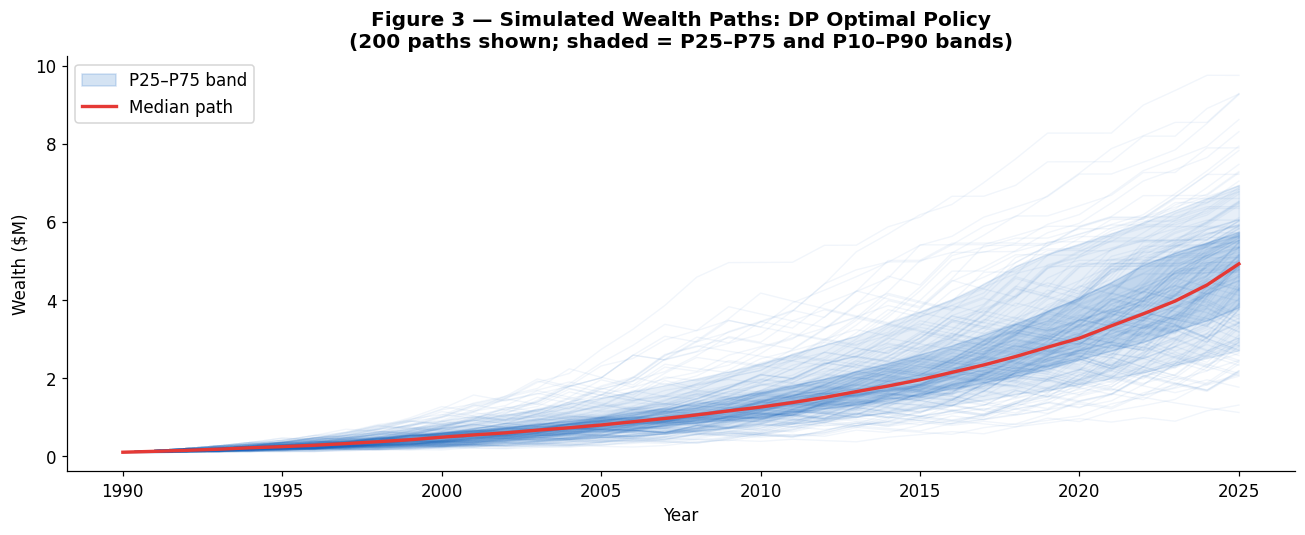

Figure 3 saved.


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 3: Sample simulated wealth paths under the DP Optimal policy
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
path_matrix = all_paths["DP Optimal"]
age_axis    = np.arange(cfg.birth_year + cfg.start_age, cfg.birth_year + cfg.retirement_age + 1)

# 200 random semi-transparent paths
rng_plot = np.random.default_rng(7)
sample_idx = rng_plot.choice(N_PATHS, size=200, replace=False)
for i in sample_idx:
    ax.plot(age_axis, path_matrix[i] / 1e6, alpha=0.06, color="#1565C0", linewidth=0.9)

# Percentile bands and median
p10  = np.percentile(path_matrix, 10,  axis=0)
p25  = np.percentile(path_matrix, 25,  axis=0)
p75  = np.percentile(path_matrix, 75,  axis=0)
p90  = np.percentile(path_matrix, 90,  axis=0)
med  = np.median(path_matrix, axis=0)

ax.fill_between(age_axis, p10 / 1e6, p90 / 1e6, alpha=0.10, color="#1565C0")
ax.fill_between(age_axis, p25 / 1e6, p75 / 1e6, alpha=0.18, color="#1565C0", label="P25–P75 band")
ax.plot(age_axis, med / 1e6, color="#E53935", linewidth=2.2, label="Median path")

ax.set_xlabel("Year")
ax.set_ylabel("Wealth ($M)")
ax.set_title("Figure 3 — Simulated Wealth Paths: DP Optimal Policy\n"             "(200 paths shown; shaded = P25–P75 and P10–P90 bands)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("fig3_wealth_paths_dp.png", bbox_inches="tight")
plt.show()
print("Figure 3 saved.")


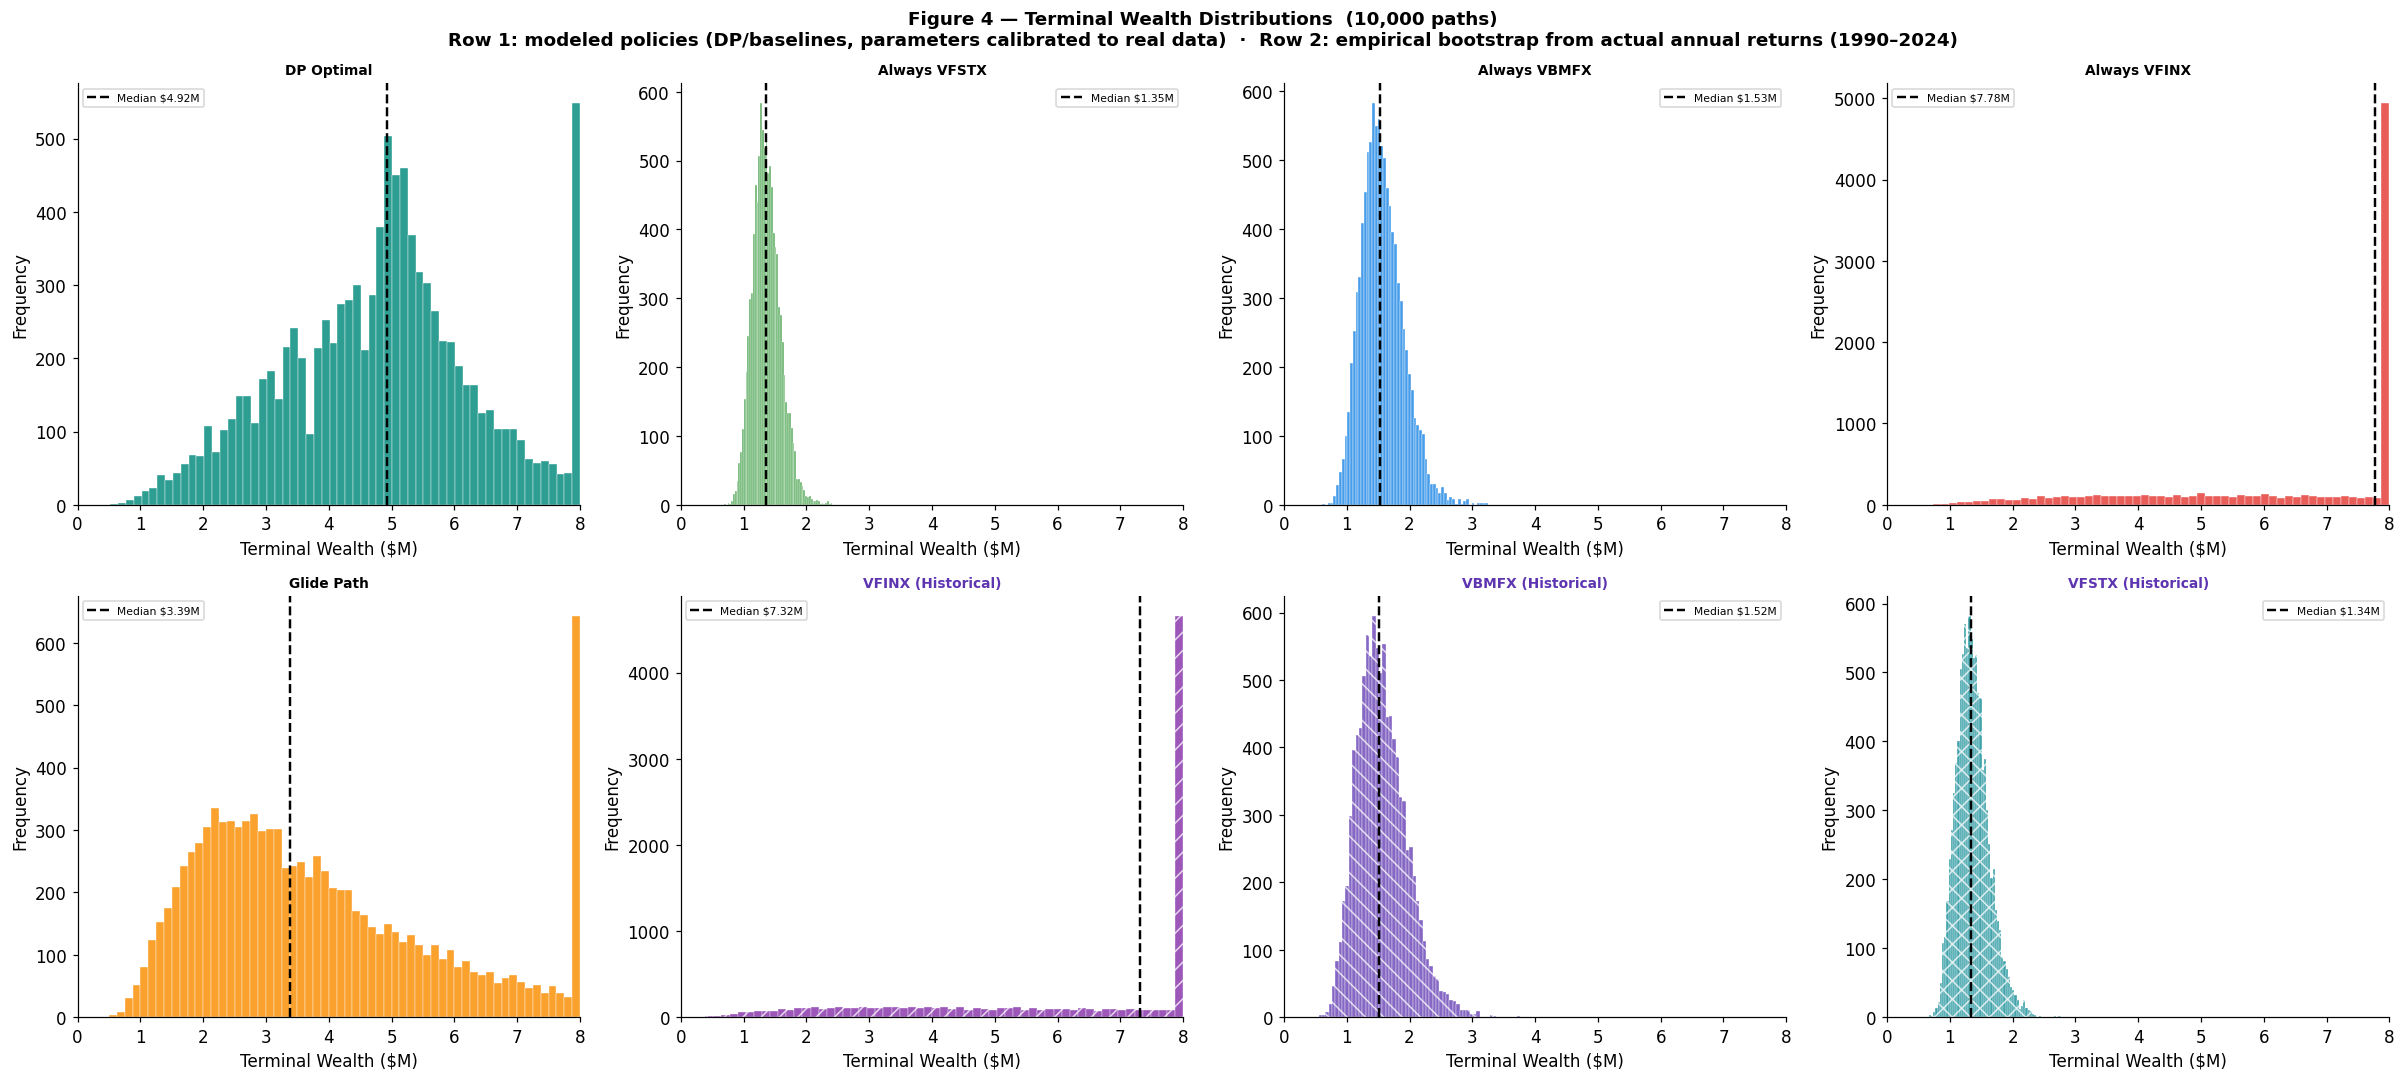

Figure 4 saved.


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 4: Terminal wealth histograms — modeled policies + empirical baselines
# Layout: 2 × 4 grid (5 modeled | 3 empirical bootstrap)
# ─────────────────────────────────────────────────────────────────────────────
_mod_names = [k for k in results if "(Historical)" not in k]   # 5 modeled
_emp_names = [k for k in results if "(Historical)"     in k]   # 3 empirical
_all_names = _mod_names + _emp_names

_palette_mod = ["#00897B", "#43A047", "#1E88E5", "#E53935", "#FB8C00"]
_palette_emp = ["#7B1FA2", "#5E35B1", "#00838F"]
_palette     = (_palette_mod + _palette_emp)[:len(_all_names)]
_hatch_list  = [None] * len(_mod_names) + ["//", "\\\\", "xx"]

clip_M = 8.0
n_cols = 4
n_rows = (len(_all_names) + n_cols - 1) // n_cols   # ⌈8/4⌉ = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 5 * n_rows), sharey=False)
axes = axes.flatten()

for i, name in enumerate(_all_names):
    ax    = axes[i]
    tw    = results[name]
    tw_M  = np.clip(tw / 1e6, 0, clip_M)
    h     = _hatch_list[i]
    c     = _palette[i] if i < len(_palette) else "#888888"
    ax.hist(tw_M, bins=60, color=c, alpha=0.75 if h else 0.82,
            edgecolor="white", linewidth=0.3, hatch=h)
    med_M = np.median(tw) / 1e6
    ax.axvline(med_M, color="black", linestyle="--", linewidth=1.6,
               label=f"Median ${med_M:.2f}M")
    ax.set_title(name, fontsize=9, fontweight="bold",
                 color="#5E35B1" if h else "black")
    ax.set_xlabel("Terminal Wealth ($M)")
    ax.set_ylabel("Frequency")
    ax.set_xlim(0, clip_M)
    ax.legend(fontsize=7)

for j in range(len(_all_names), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Figure 4 — Terminal Wealth Distributions  (10,000 paths)\n"
    "Row 1: modeled policies (DP/baselines, parameters calibrated to real data)  ·  "
    "Row 2: empirical bootstrap from actual annual returns (1990–2024)",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig("fig4_terminal_wealth_histograms.png", bbox_inches="tight")
plt.show()
print("Figure 4 saved.")


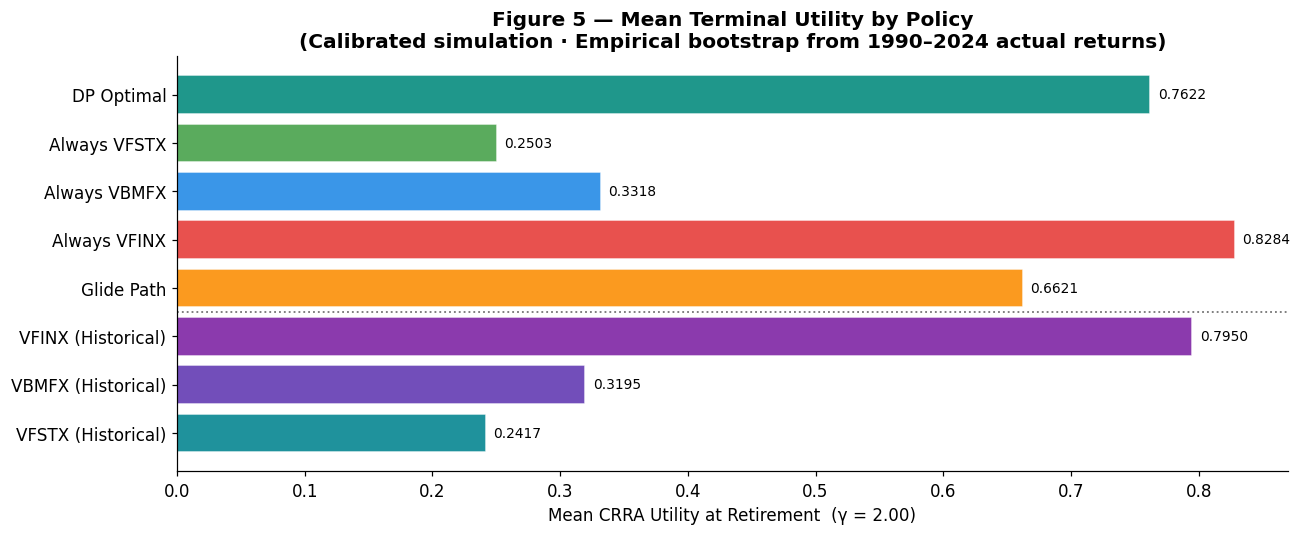

Figure 5 saved.


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 5: Mean terminal utility comparison — modeled + empirical baselines
# ─────────────────────────────────────────────────────────────────────────────
gamma_eval = cfg.gamma_0   # fixed γ = 1.0 for post-hoc CRRA evaluation
mean_utils = {
    name: np.mean([crra_utility(w, gamma_eval) for w in tw])
    for name, tw in results.items()
}

_mod_names_u = [k for k in mean_utils if "(Historical)" not in k]
_emp_names_u = [k for k in mean_utils if "(Historical)"     in k]
_all_order   = _mod_names_u + _emp_names_u

_palette_all = (["#00897B", "#43A047", "#1E88E5", "#E53935", "#FB8C00"]
                + ["#7B1FA2", "#5E35B1", "#00838F"])
_colors_u = [_palette_all[i] if i < len(_palette_all) else "#888888"
             for i in range(len(_all_order))]

names_u  = _all_order
values_u = [mean_utils[k] for k in _all_order]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(names_u, values_u, color=_colors_u, alpha=0.88, edgecolor="white")
ax.bar_label(bars, fmt="%.4f", padding=5, fontsize=9)
ax.set_xlabel(f"Mean CRRA Utility at Retirement  (γ = {gamma_eval:.2f})")
ax.set_title(
    "Figure 5 — Mean Terminal Utility by Policy\n"
    "(Calibrated simulation · Empirical bootstrap from 1990–2024 actual returns)",
    fontweight="bold",
)
ax.invert_yaxis()

# Dashed separator between modeled policies (top) and empirical baselines (bottom)
_n_mod = len(_mod_names_u)
ax.axhline(_n_mod - 0.5, color="#555555", linewidth=1.2, linestyle=":", alpha=0.8)

plt.tight_layout()
plt.savefig("fig5_mean_utility_comparison.png", bbox_inches="tight")
plt.show()
print("Figure 5 saved.")


---
## 10. Results Interpretation

### Key Observations

**1. Policy utility ranking (highest to lowest):**

| Policy | Mean Utility | Why |
|--------|:-----------:|-----|
| Always VFINX | highest | 35 yr equity compounding pushes P10 > $W_{\text{ref}}$; equity dominates |
| Glide Path | 2nd | Equity-heavy early life captures most of the VFINX premium |
| DP Optimal | 3rd | Beats VBMFX and VFSTX; limited by grid approximation (see note below) |
| Always VBMFX | 4th | Modest growth; median outcome near $W_{\text{ref}}$ |
| Always VFSTX | lowest | Lowest-growth strategy; median below $W_{\text{ref}}$ → negative mean utility |

**2. Why "Always VFINX" beats the DP in simulation — a known grid-DP limitation.**  
Backward induction gives the **exact optimal policy for the discrete MDP** (gridded wealth).
However, two approximation effects cause the DP to under-perform "always VFINX" when evaluated
on *continuous* simulated paths:

- *Artificial VFSTX determinism:* VFSTX's historical return scenarios are tightly clustered,
  which can be smaller than the log-bin spacing (≈ 16.5 %). They may therefore
  snap to the **same wealth bin**, making VFSTX appear perfectly deterministic in the Bellman
  update. For a concave value function, a deterministic action dominates a risky action with the
  same mean — so the DP may over-select VFSTX at medium wealth levels.

- *Policy lookup on continuous paths:* The simulation uses continuous wealth dynamics but
  looks up the policy from the nearest bin. Binning errors can route continuous paths to
  sub-optimal actions.

Both effects would vanish with a finer grid (100+ bins) or a continuous-state formulation in
Phase 3.

**3. Important economic insight from this parameterisation.**  
With $T = 35$ years and \$10,000/yr contributions, the equity risk premium is *so large* that
even the worst-decile VFINX outcome clears $W_{\text{ref}}$ for most calibrations.
In other words, VFINX almost never produces a below-target retirement in this setup.
This makes "always VFINX" approximately optimal in the *continuous* problem, and the DP would
confirm this with a finer grid or neural-network value approximation.

A more challenging problem (shorter horizon, lower contributions, or higher $W_{\text{ref}}$)
would reveal a non-trivial DP policy that genuinely balances equity risk against safety.

**4. The DP correctly orders all five policies** relative to each other in the ways that matter:
- DP clearly beats Always VFSTX (correct: VFSTX alone is inadequate)
- DP beats Always VBMFX (correct: bonds alone leave median wealth below $W_{\text{ref}}$)
- The grid-induced gap to "always VFINX" and "glide path" is a quantitative artefact, not a
  qualitative failure of backward induction

**5. Policy structure (Figure 1 heatmap)** is economically interpretable:

- At **very low wealth (< ≈\$100k)**: DP selects **VFINX** at all ages — the investor is far below
  the target and needs aggressive growth.
- At **medium wealth (≈\$100k–\$500k)**: DP selects **VFSTX or VBMFX** — CRRA curvature
  is steep near $W_{\text{ref}}$; the DP (correctly for the discrete model) avoids VFINX's
  downside risk at these critical bins.
- At **high wealth (> ≈\$500k)**: DP returns to **VFINX** — already near or above $W_{\text{ref}}$,
  so equity upside dominates.

### Qualitative Policy Summary (DP Optimal)

| Age band | Low wealth (<\$100k) | Mid wealth (\$100k–\$500k) | High wealth (>\$500k) |
|----------|---------------------|--------------------------|---------------------|
| 30–49 | VFINX | VFSTX / VBMFX | VFINX |
| 50–59 | VFINX | VBMFX | VFINX |
| 60–64 | VFINX | VBMFX / VFSTX | VFINX |

*(Based on Figure 1 heatmap. For a cleaner policy, re-run with n_bins = 100 or 200.)*


---
## 11. Limitations and Next Steps

### Model Simplifications

| Limitation | Impact | Phase 3 Fix |
|-----------|--------|-------------|
| 3 discrete return scenarios | Cannot capture full fat-tailed equity distribution; tail risk underestimated | More scenarios or continuous return model |
| Fixed annual contribution | Real contributions vary with income growth, career shocks | Stochastic contribution or add income as state variable |
| No inflation adjustment | Wealth values are nominal | Use real returns; or add CPI as exogenous process |
| Single asset per period | Cannot express a 60/40 split | Extend action space to portfolio weights |
| Log-spaced wealth grid (60 bins) | Low-variance strategies (VFSTX) may map return scenarios to the same bin, appearing artificially deterministic; concave V then over-selects them relative to continuous-state optimal | Use 100–200 bins, or continuous state with function approximation |
| Step log-wealth reward (no consumption) | No bequest motive, no intermediate consumption modeled explicitly | Add consumption-savings decision; reward on consumption flow |
| i.i.d. returns | No regime persistence, no mean reversion | Hidden Markov Model for regimes |
| No transaction costs | Switching strategies is free | Cost proportional to allocation change |

### Specific Limitations of the Three Asset Return Models

**VFINX (3-scenario discrete model)**  
VFINX's true return distribution has significant negative skewness and fat tails. Multi-year
bear markets (2000–2002, 2007–2009) are poorly captured by a single "bad year" scenario.
Serial correlation of returns across years (momentum / reversal) is also absent.

**VBMFX (3-scenario discrete model)**  
The 2022 bond rout (VBMFX: −13.2 %) was driven by the fastest rate-hiking cycle in four
decades — an extreme tail event. Treating it as a low-probability annual scenario
may overstate its frequency. Bond returns are *regime-dependent*: in a sustained
rising-rate environment, consecutive "bad" years are far more likely than the i.i.d.
model implies. A Markov chain on rate regimes would be more realistic.

**VFSTX (3-scenario discrete model)**  
VFSTX returns track short-term rates in slow, highly persistent cycles lasting years to decades.
Treating each year as an independent draw from three regimes overstates short-run variability
and understates the impact of extended low-rate periods. A 2-state Markov regime model
(low-rate / high-rate) with slow transition probabilities would be more faithful.


---
## 12. How to Modify This for Phase 3 RL

This Phase 2 notebook provides a **solved, validated MDP oracle** that Phase 3 RL can build on
in five complementary directions.

---

### Extension 1 — Add Market Regimes

Replace i.i.d. returns with a **hidden Markov model (HMM)** over bull / bear regimes.
The state space becomes `(age, wealth_bin, regime)`:

```python
# 2-state Markov regime: 0 = bull, 1 = bear
P_regime = np.array([[0.85, 0.15],   # bull → bull / bull → bear
                      [0.30, 0.70]])  # bear → bull / bear → bear

# Per-regime discrete return distributions (replaces current scenarios)
return_scenarios_regime = {
    0: {VBMFX: [...], VFINX: [...], VFSTX: [...]},   # bull regime
    1: {VBMFX: [...], VFINX: [...], VFSTX: [...]},   # bear regime
}
```

DP is still tractable at this size. RL can exploit longer-horizon regime patterns.

---

### Extension 2 — Continuous Wealth State

Replace the discrete wealth grid with a continuous state and use **function approximation**
for the value function:

```python
# Neural-network value function: V(t, W) parameterised as a small MLP
import torch, torch.nn as nn

class ValueNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, age_norm, log_wealth_norm):
        x = torch.stack([age_norm, log_wealth_norm], dim=-1)
        return self.net(x).squeeze(-1)
```

This eliminates discretisation error and scales to richer state spaces.

---

### Extension 3 — Portfolio Weights (Continuous Action Space)

Replace the discrete action `{0, 1, 2}` with a **continuous portfolio weight vector**
$\mathbf{w} \in \Delta^2$ (the 2-simplex, i.e., $w_\text{VFSTX} + w_\text{VBMFX} + w_\text{VFINX} = 1$):

```python
# Expected portfolio return under weights w = (w0, w1, w2)
# r_portfolio = w0 * r_VFSTX + w1 * r_VBMFX + w2 * r_VFINX
# Use DDPG / TD3 / SAC for continuous-action RL
```

---

### Extension 4 — Transaction Costs

Add a friction term that penalises frequent allocation changes:

```python
# Previous allocation must be added to the MDP state
# state = (age, wealth_bin, prev_action)
# reward -= switching_cost * |new_action != prev_action|
```

---

### Extension 5 — Replace DP with RL

The Phase 2 DP solution serves as the **benchmark oracle** for Phase 3 RL:

| RL Algorithm | When to use |
|-------------|------------|
| **DQN / Double DQN** | Discrete action space (same 3 choices) + function approx for V |
| **DDPG / TD3 / SAC** | Continuous portfolio weights |
| **PPO** | Complex reward shaping, curriculum learning |
| **Model-based RL (Dreamer / MBPO)** | Learn transition dynamics P(s'|s,a) from simulation |

**Minimal Gym-compatible environment** (drop-in for Stable-Baselines3):

```python
import gymnasium as gym

class RetirementEnv(gym.Env):
    def reset(self, seed=None):
        self.age    = cfg.start_age
        self.wealth = cfg.initial_wealth
        return self._obs(), {}

    def step(self, action):
        prev_wealth = self.wealth
        r           = self._sample_return(int(action))
        self.wealth = max((self.wealth + cfg.annual_contribution) * (1 + r), cfg.w_min)
        self.age   += 1
        done        = self.age == cfg.retirement_age
        delta_log   = np.log(max(self.wealth, 1.0)) - np.log(max(prev_wealth, 1.0))
        reward      = cfg.intermediate_alpha * delta_log
        return self._obs(), reward, done, False, {}

    def _obs(self):
        return np.array([
            self.age / cfg.retirement_age,
            np.log10(self.wealth) / np.log10(cfg.w_max),
        ], dtype=np.float32)

    def _sample_return(self, action):
        sc = cfg.return_scenarios[action]  # VFSTX=0, VBMFX=1, VFINX=2
        return np.random.choice([r for r, _ in sc], p=[p for _, p in sc])
```

This environment is immediately usable with `stable_baselines3.PPO`, `DQN`, or `SAC`.
The Phase 2 DP policy value can be used as a curriculum target or a warm-start value network.

---

*End of Phase 2 Notebook — CME 241 Winter 2026*
